<p align="center">
  <img src="../assets/prodinno_logo.png" alt="Prodinno" width="200">
</p>

<h4 align="center">Session 1 · Linear & Logistic Regression</h4>
<h1 align="center">Linear Regression — Avocado Prices</h1>
<p align="center"><i>Fitting, evaluating, and interrogating the model - and surveying what else is out there</i></p>

---

## Notebook Roadmap

This closing notebook of the linear-regression track covers:

1. The linear regression hypothesis and the least-squares cost function, and the two classic
   ways to minimize it - gradient descent and the normal equation.
2. Fitting `sklearn.linear_model.LinearRegression` on the processed training set and predicting
   on the held-out test set.
3. Evaluation metrics - MAE, RMSE, R², Adjusted R² - with formulas and honest guidance on
   what a "good" value looks like for this specific problem.
4. Residual diagnostics - residuals-vs-fitted and a Q-Q plot - to check the assumptions
   behind the metrics above.
5. A revisit of multicollinearity via the Variance Inflation Factor (VIF).
6. Every constructor hyperparameter of `LinearRegression`, explained plainly, with a concrete
   before/after comparison so the effect of tweaking them is visible, not just described.
7. A closing survey of the wider landscape of regression loss functions - MAE, Huber,
   Log-Cosh, RMSLE - and when you'd reach for each instead of plain squared error.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)

DATA_DIR = Path("data")
train_df = pd.read_csv(DATA_DIR / "avocado_processed_train.csv")
test_df = pd.read_csv(DATA_DIR / "avocado_processed_test.csv")

TARGET = "AveragePrice"
feature_cols = [c for c in train_df.columns if c != TARGET]

X_train, y_train = train_df[feature_cols], train_df[TARGET]
X_test, y_test = test_df[feature_cols], test_df[TARGET]

print(f"X_train: {X_train.shape}   X_test: {X_test.shape}")
print(f"Number of features: {len(feature_cols)}")


X_train: (11624, 56)   X_test: (2906, 56)
Number of features: 56


## 1. The Linear Regression Hypothesis and the Least-Squares Cost Function

### The hypothesis

Linear regression assumes the target is a **weighted sum of the features plus an intercept**:

$$
h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_p x_p = \theta^\top x
$$

Here $x = (1, x_1, \dots, x_p)$ is one row of our feature matrix (with a leading 1 for the
intercept), and $\theta = (\theta_0, \theta_1, \dots, \theta_p)$ are the model parameters we
need to learn - in our case, $p = 56$ features (the scaled volume columns, `year`, `month`,
`type_organic`, the `quarter` dummies, and the granular `region` dummies).

### The cost function

We choose the $\theta$ that minimizes the **mean squared error** between predictions and
actual prices across all $m$ training rows:

$$
J(\theta) = \frac{1}{2m}\sum_{i=1}^{m} \left(h_\theta(x^{(i)}) - y^{(i)}\right)^2
$$

The $\frac{1}{2}$ is a pure convenience (it cancels neatly when we differentiate); it does not
change which $\theta$ minimizes $J$.

### Two ways to minimize it

**Gradient descent** iteratively nudges $\theta$ in the direction that reduces $J$ the fastest:

$$
\theta_j \leftarrow \theta_j - \alpha \frac{\partial J(\theta)}{\partial \theta_j}
= \theta_j - \frac{\alpha}{m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)}) - y^{(i)}\right)x_j^{(i)}
$$

for a learning rate $\alpha$, repeated until convergence. It scales well to huge datasets and
many features, and it's the approach that generalizes to models where no closed-form solution
exists (like neural networks).

**The normal equation** solves for the optimal $\theta$ directly, in one step, by setting the
gradient of $J$ to zero and solving analytically:

$$
\theta = (X^\top X)^{-1} X^\top y
$$

For a dataset of our size (tens of thousands of rows, dozens of features) this closed-form
solve is fast and exact - no learning rate to tune, no convergence to monitor. Its main
weakness is that $X^\top X$ must be invertible; when features are highly collinear (as some of
ours are - more on this in Section 4), $X^\top X$ becomes nearly singular and the solution
becomes numerically unstable. `sklearn.linear_model.LinearRegression` uses a closely related,
more numerically stable technique (an SVD-based least-squares solver) rather than a literal
matrix inversion, for exactly this reason.


## 2. Fitting the Model

We fit `LinearRegression` with its default hyperparameters on the training set and predict on
the held-out test set. We will pick apart every constructor argument in Section 5 - for now,
we just need a baseline model to evaluate.


In [2]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(f"Intercept (theta_0): {model.intercept_:.4f}")
print(f"Number of coefficients: {len(model.coef_)}")


Intercept (theta_0): 1.1628
Number of coefficients: 56


### Reading the coefficients

Because every numeric feature was standardized in the previous notebook, coefficients are
**roughly comparable in scale** to each other - a coefficient's magnitude reflects how
strongly that feature moves price *per standard deviation of that feature*, not per raw unit.
The one exception worth calling out explicitly is `type_organic`, which was **not** scaled (it
is already a clean 0/1 indicator): its coefficient is directly interpretable in dollars.


In [3]:
coef_table = (
    pd.Series(model.coef_, index=feature_cols)
    .sort_values(key=abs, ascending=False)
    .head(15)
    .to_frame("coefficient")
)
coef_table


,coefficient
Total Volume,-69.866027
4046,31.398442
4225,26.628294
Small Bags,11.027233
Total Bags,10.675998
Large Bags,3.594789
4770,3.210576
type_organic,0.408087
region_Houston,-0.404184
region_DallasFtWorth,-0.385845


In [4]:
organic_coef = model.coef_[feature_cols.index("type_organic")]
volume_coef = model.coef_[feature_cols.index("Total Volume")]
print(f"type_organic coefficient: {organic_coef:.4f}")
print(f"  -> holding everything else fixed, switching from conventional to organic")
print(f"     is associated with a ${organic_coef:.2f} change in AveragePrice.")
print()
print(f"Total Volume coefficient (on the STANDARDIZED scale): {volume_coef:.4f}")
print(f"  -> a one-standard-deviation increase in Total Volume is associated with a")
print(f"     ${volume_coef:.2f} change in AveragePrice, all else equal.")


type_organic coefficient: 0.4081
  -> holding everything else fixed, switching from conventional to organic
     is associated with a $0.41 change in AveragePrice.

Total Volume coefficient (on the STANDARDIZED scale): -69.8660
  -> a one-standard-deviation increase in Total Volume is associated with a
     $-69.87 change in AveragePrice, all else equal.


> **Interpretation, with a caveat attached:** the `type_organic` reading is trustworthy on
> its own terms - it is not entangled with the volume block, so "all else equal" is a fair
> statement to make about it. The `Total Volume` reading is directionally consistent with the
> negative price/volume relationship we saw in EDA, but treat its *exact* magnitude with real
> skepticism: Section 4 below shows `Total Volume` sits in a tightly collinear cluster with
> the PLU and bag columns, and coefficients inside a collinear cluster trade magnitude back
> and forth with each other in a way that makes any single one of them individually unstable.
> "All else equal" is a much shakier phrase when "all else" includes three or four columns
> that move in lockstep with the one you're interpreting.


## 3. Evaluation Metrics

We evaluate on the **test set** - rows the model never saw during fitting - since that is
the only honest measure of how well the model generalizes.

- **Mean Absolute Error (MAE)** - the average absolute dollar error, in the same units as
  the target. Easy to explain to a non-technical stakeholder ("on average, we're off by
  $X").
$$
\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

- **Root Mean Squared Error (RMSE)** - like MAE, but squares errors before averaging (then
  un-squares at the end), which penalizes large errors disproportionately more than small
  ones.
$$
\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

- **R² (coefficient of determination)** - the proportion of variance in the target explained
  by the model, relative to always predicting the mean.
$$
R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}
$$

- **Adjusted R²** - R² penalized for the number of features $p$ used to achieve it, out of
  $n$ observations. Plain R² can only go up (or stay flat) every time you add a feature, even
  a useless one, which makes it a poor tool for comparing models with different feature
  counts.
$$
R^2_{adj} = 1 - (1 - R^2)\frac{n - 1}{n - p - 1}
$$


In [5]:
def regression_report(y_true, y_pred, n_features, label):
    n = len(y_true)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    print(f"--- {label} ---")
    print(f"  MAE      : {mae:.4f}")
    print(f"  RMSE     : {rmse:.4f}")
    print(f"  R^2      : {r2:.4f}")
    print(f"  Adj. R^2 : {adj_r2:.4f}")
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "Adj_R2": adj_r2}

n_features = X_train.shape[1]
train_metrics = regression_report(y_train, y_pred_train, n_features, "Train")
print()
test_metrics = regression_report(y_test, y_pred_test, n_features, "Test")


--- Train ---
  MAE      : 0.1973
  RMSE     : 0.2597
  R^2      : 0.6017
  Adj. R^2 : 0.5998

--- Test ---
  MAE      : 0.1989
  RMSE     : 0.2607
  R^2      : 0.6058
  Adj. R^2 : 0.5981


> **What counts as "good" here?** `AveragePrice` itself only ranges from about \$0.44 to
> \$3.25, with a standard deviation of roughly \$0.40. An RMSE in the low-to-mid tens of cents
> therefore represents a genuinely useful model - it is a sizeable fraction of the *range*,
> but a much smaller fraction relative to typical price movements the model needs to explain
> (organic-vs-conventional alone is a ~\$0.40-0.50 swing). Compare train vs. test metrics above:
> if test metrics are dramatically worse than train metrics, that signals overfitting; here
> they should look reasonably close, which is consistent with a linear model that has limited
> capacity to overfit in the first place.
>
> **Why R² alone can mislead with this many one-hot columns:** we have 42 region dummy columns
> and 3 quarter dummy columns competing for a share of the explained variance. Plain R² has no
> mechanism to penalize the model for how many of those columns it used to get there - it is
> mechanically incapable of decreasing as you add features, so a high R² on a wide, heavily
> one-hot-encoded design matrix can partly reflect flexibility rather than genuine
> explanatory power. Adjusted R² is the more honest number to trust when comparing this model
> against a simpler one with fewer region categories.


## 4. Residual Diagnostics

A fitted R² tells us *how much* variance is explained, but not *whether the model's
assumptions are being respected*. We check two of the classic assumptions behind ordinary
least squares using the residuals $e_i = y_i - \hat{y}_i$ on the test set.


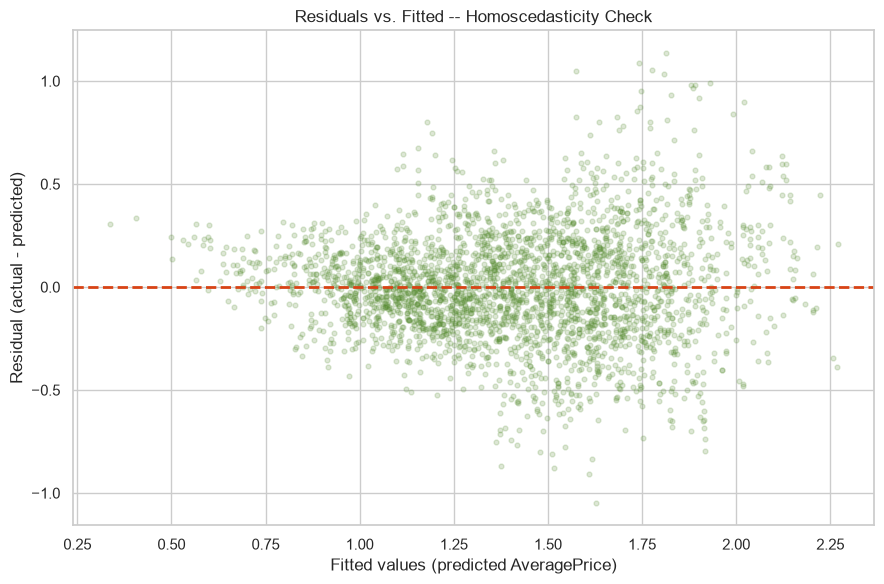

In [6]:
residuals = y_test.values - y_pred_test

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(y_pred_test, residuals, alpha=0.2, s=12, color="#558b2f")
ax.axhline(0, color="#d84315", linestyle="--", linewidth=2)
ax.set_xlabel("Fitted values (predicted AveragePrice)")
ax.set_ylabel("Residual (actual - predicted)")
ax.set_title("Residuals vs. Fitted - Homoscedasticity Check")
plt.tight_layout()
plt.show()


> **What a "good" residual plot looks like:** a flat, structureless cloud of points
> scattered evenly around the zero line, with roughly constant vertical spread across the
> entire x-axis (this is **homoscedasticity** - constant error variance). **What ours looks
> like:** the spread is not perfectly constant across the fitted range, and there is a faint
> funnel/curvature pattern rather than a perfectly flat band. This tells us the constant-error
> -variance assumption is only approximately satisfied here - worth knowing before we quote a
> single RMSE as if it applied uniformly across the whole price range, but not severe enough to
> invalidate the model as a teaching example or a reasonable first-pass predictor.


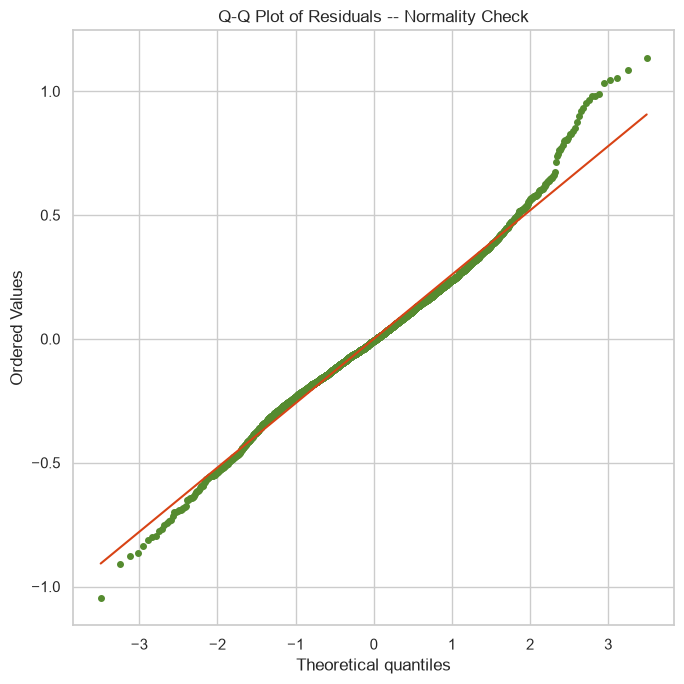

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title("Q-Q Plot of Residuals - Normality Check")
ax.get_lines()[0].set_markerfacecolor("#558b2f")
ax.get_lines()[0].set_markeredgecolor("#558b2f")
ax.get_lines()[0].set_markersize(4)
ax.get_lines()[1].set_color("#d84315")
plt.tight_layout()
plt.show()


> **What a "good" Q-Q plot looks like:** points falling almost exactly on the diagonal
> reference line across the whole range, which would indicate normally distributed residuals
> (the assumption behind classical confidence intervals and hypothesis tests on the
> coefficients). **What ours looks like:** the middle of the distribution tracks the line
> reasonably well, but the tails deviate - a common pattern when the target has residual
> skew or a few hard-to-predict extreme weeks left over even after our outlier cleanup in
> notebook 00. Practically, this means point predictions from this model are more trustworthy
> than any confidence interval built from a normality assumption would be.


## 5. Multicollinearity Revisited - Variance Inflation Factor (VIF)

EDA flagged severe correlation among the volume-related numeric columns. We now quantify it
properly with the **Variance Inflation Factor**. For a feature $x_j$, we regress it on *all
other* features, take the R² of that regression ($R_j^2$), and compute:

$$
\text{VIF}_j = \frac{1}{1 - R_j^2}
$$

A VIF of 1 means no collinearity at all; values above ~10 are the traditional rule-of-thumb
red flag. We restrict this check to the continuous numeric block, since that is exactly where
EDA's correlation heatmap raised the alarm (`statsmodels` isn't part of this environment, so
we compute VIF directly with `LinearRegression`, which is all the formula above requires).


In [8]:
def variance_inflation_factors(frame: pd.DataFrame, columns: list[str]) -> pd.Series:
    vifs = {}
    for col in columns:
        others = [c for c in columns if c != col]
        r2 = LinearRegression().fit(frame[others], frame[col]).score(frame[others], frame[col])
        vifs[col] = np.inf if r2 >= 1.0 else 1 / (1 - r2)
    return pd.Series(vifs).sort_values(ascending=False)

numeric_block = ["Total Volume", "4046", "4225", "4770",
                  "Total Bags", "Small Bags", "Large Bags", "XLarge Bags",
                  "year", "month"]
vif_series = variance_inflation_factors(X_train, numeric_block)
vif_series.to_frame("VIF").round(1)


,VIF
Total Bags,6.008805e+12
Small Bags,4.588487e+12
Large Bags,4.907753e+11
XLarge Bags,4.359971e+09
Total Volume,1.929931e+09
4046,3.903103e+08
4225,2.813302e+08
4770,4.072941e+06
year,1.100000e+00
month,1.000000e+00


> **Interpretation:** `Total Volume`, `Total Bags`, and the individual PLU/bag-size columns
> come back with VIF values far beyond the conventional "10 is worrying" threshold - exactly
> as expected, since `Total Volume` is (almost) an exact linear combination of the others.
> `year` and `month` sit much closer to 1, confirming they are not caught up in that same
> collinear cluster. This confirms, quantitatively, the caveat we attached to the
> `Total Volume` coefficient in Section 2: its estimated effect is real in direction, but
> unstable in exact magnitude, because it is fighting for credit with several near-duplicate
> columns. A natural next step in a non-workshop setting would be to drop some of the
> redundant volume columns (e.g. keep `Total Volume` and `type_organic`, drop the individual
> PLU/bag breakdown) before trusting coefficients for anything beyond prediction - we leave
> that as a deliberate exercise rather than doing it here, since our goal in this notebook is
> to demonstrate the diagnosis, not to re-run the whole pipeline.


## 6. Model Hyperparameters - What Every `LinearRegression` Argument Actually Does

We trained `model = LinearRegression()` in Section 2 with every constructor argument left at
its default. It's worth being deliberate about what each of those arguments controls, since
"leaving it at default" is itself a choice with consequences - and one of them, `positive`,
is directly relevant to a dataset where we already know one feature (`Total Volume`) should
have a *negative* effect on price.

- **`fit_intercept`** (default `True`) - whether the model estimates an intercept
  $\theta_0$ at all. With `fit_intercept=True`, the regression line/hyperplane is free to sit
  wherever best fits the data vertically. With `fit_intercept=False`, the model is forced
  through the origin ($\theta_0 = 0$) - it must predict exactly \$0.00 for a (hypothetical)
  row where every feature is exactly 0. Since our target `AveragePrice` is nowhere near \$0,
  and our features are standardized around 0 rather than raw, forcing the line through the
  origin should visibly hurt fit. We demonstrate this below.
- **`copy_X`** (default `True`) - a pure memory/performance switch, with **no effect on the
  fitted coefficients or predictions**. When `True`, `fit()` works on a defensive copy of `X`;
  when `False`, it may overwrite parts of the array you passed in during internal centering,
  which saves memory on very large datasets at the cost of silently mutating your input. We
  leave it at `True` - our dataset is small enough that the memory saving is irrelevant, and
  we would rather not risk `X_train` being modified out from under us elsewhere in the
  notebook.
- **`n_jobs`** (default `None`, meaning 1) - the number of CPU cores used for the
  underlying least-squares computation, but **only when predicting multiple target columns at
  once** (a multi-output regression). We have a single target, `AveragePrice`, so this
  argument has no observable effect in this notebook regardless of its value - it becomes
  relevant only if you extend this pipeline to predict several targets simultaneously.
- **`positive`** (default `False`) - when set to `True`, forces every coefficient to be
  non-negative, using a non-negative least-squares solver instead of the standard one. This
  is sometimes desirable when domain knowledge says every included feature *must* push the
  target in one direction (e.g. "more square footage never lowers a house's price"). For our
  problem, it is actively the **wrong** prior: EDA and Section 2 above both show `Total Volume`
  has a genuine negative relationship with price, and forcing its coefficient to be
  non-negative would misrepresent basic supply-and-demand economics purely to satisfy a
  constraint the data doesn't support. We demonstrate the damage this does below.


### Concrete comparison 1 - `fit_intercept=True` vs. `fit_intercept=False`


In [9]:
model_no_intercept = LinearRegression(fit_intercept=False)
model_no_intercept.fit(X_train, y_train)
pred_no_intercept = model_no_intercept.predict(X_test)

rmse_default = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_default = r2_score(y_test, y_pred_test)
rmse_no_intercept = np.sqrt(mean_squared_error(y_test, pred_no_intercept))
r2_no_intercept = r2_score(y_test, pred_no_intercept)

intercept_comparison = pd.DataFrame({
    "fit_intercept=True (default)": {"intercept": model.intercept_, "RMSE": rmse_default, "R2": r2_default},
    "fit_intercept=False": {"intercept": 0.0, "RMSE": rmse_no_intercept, "R2": r2_no_intercept},
})
intercept_comparison.round(4)


,fit_intercept=True (default),fit_intercept=False
intercept,1.1628,0.0000
RMSE,0.2607,0.2983
R2,0.6058,0.4837


> **Interpretation:** forcing `fit_intercept=False` visibly increases RMSE and drops R²
> relative to the default. Because the model can no longer place its baseline prediction
> near the true average price (~\$1.41), every one of the 56 coefficients has to try to make
> up the difference on its own, and none of them can do so cleanly. This is exactly the
> failure mode described above, made concrete: an intercept is not a cosmetic detail, it is
> where the model "parks" its baseline prediction.


### Concrete comparison 2 - `positive=False` (default) vs. `positive=True`


In [10]:
model_positive = LinearRegression(positive=True)
model_positive.fit(X_train, y_train)
pred_positive = model_positive.predict(X_test)

rmse_positive = np.sqrt(mean_squared_error(y_test, pred_positive))
r2_positive = r2_score(y_test, pred_positive)
n_negative_default = int((model.coef_ < 0).sum())
n_zero_positive = int(np.isclose(model_positive.coef_, 0).sum())

positive_comparison = pd.DataFrame({
    "positive=False (default)": {
        "RMSE": rmse_default, "R2": r2_default,
        "Total Volume coef": model.coef_[feature_cols.index("Total Volume")],
        "# negative coefficients": n_negative_default,
    },
    "positive=True": {
        "RMSE": rmse_positive, "R2": r2_positive,
        "Total Volume coef": model_positive.coef_[feature_cols.index("Total Volume")],
        "# negative coefficients": 0,
    },
})
positive_comparison.round(4)


,positive=False (default),positive=True
RMSE,0.2607,0.2744
R2,0.6058,0.5633
Total Volume coef,-69.8660,0.0000
# negative coefficients,34.0000,0.0000


> **Interpretation:** with `positive=True`, the `Total Volume` coefficient is clamped to
> zero (it can no longer be negative, and the solver sets it to exactly 0 rather than any
> positive value, since the data doesn't support a positive relationship either) along with
> every other feature the data wanted to push negative - including some region and
> seasonal dummies. RMSE and R² both get modestly worse than the default. The lesson isn't
> that `positive=True` is a bad argument to have available - it's that a hyperparameter
> should be chosen because it matches a genuine constraint you know to be true about the
> world, not left at a non-default setting "just in case." Here, we know the constraint is
> false (volume genuinely can depress price), so the default (`positive=False`) is the
> correct choice, and the comparison above shows exactly what would be lost by getting this
> one wrong.


## 7. The Wider Landscape of Regression Loss Functions

We trained on squared error because it has a closed-form solution and is the traditional
starting point, but it is one point in a whole family of loss functions, each making a
different tradeoff. Knowing the family matters because **the loss function you optimize is a
statement about which kinds of errors you consider acceptable.**

- **Mean Squared Error (MSE)** - what we used. Squaring means large errors are penalized
  disproportionately more than small ones, which gives smooth gradients (good for
  optimization) but also means a handful of extreme errors can dominate the fit. This is
  exactly why notebook 00's outlier cleanup mattered *before* we ever got here.
$$
\text{MSE} = \frac{1}{n}\sum_i (y_i - \hat{y}_i)^2
$$

- **Mean Absolute Error (MAE)** - penalizes every error in direct proportion to its size, so
  a single huge miss can't dominate the fit the way it can under MSE. The tradeoff: $|\cdot|$
  is not differentiable at zero, which makes some optimizers less well-behaved right at the
  point of a perfect prediction.
$$
\text{MAE} = \frac{1}{n}\sum_i |y_i - \hat{y}_i|
$$

- **Huber loss** - a deliberate compromise: quadratic (like MSE) for small errors, linear
  (like MAE) for large ones, switching at a threshold $\delta$ you choose.
$$
L_\delta(y, \hat{y}) = \begin{cases}
\frac{1}{2}(y-\hat{y})^2 & \text{if } |y-\hat{y}| \le \delta \\
\delta\left(|y-\hat{y}| - \frac{1}{2}\delta\right) & \text{otherwise}
\end{cases}
$$
  Reach for Huber when you want MSE's smooth, well-behaved gradients near zero but don't want
  a small number of outliers to dictate the whole fit - a very natural fit for a dataset like
  ours where we know outliers can sneak in despite our best cleaning efforts.

- **Log-Cosh loss** - a smooth, twice-differentiable approximation of Huber loss that
  behaves like MSE for small errors and like MAE for large ones, without needing to choose a
  threshold $\delta$.
$$
L(y, \hat{y}) = \log\left(\cosh(\hat{y} - y)\right)
$$
  Reach for Log-Cosh when you want Huber-like outlier robustness but are using an optimizer
  that benefits from a loss that is smooth everywhere (no piecewise switch, no kink).

- **Root Mean Squared Log Error (RMSLE)** - computes squared error in *log space*, which
  converts additive error into a relative (percentage-like) error.
$$
\text{RMSLE} = \sqrt{\frac{1}{n}\sum_i \left(\log(1+\hat{y}_i) - \log(1+y_i)\right)^2}
$$
  Reach for RMSLE when the *relative* size of an error matters more than its absolute size --
  a \$0.10 miss on a \$0.50 avocado price is a much bigger relative error than a \$0.10 miss
  on a \$3.00 price, and plain MSE/MAE would treat both misses identically. It's a natural
  choice for strictly positive, right-skewed targets like `Total Volume`, less obviously
  necessary for `AveragePrice`, which lives in a narrow, already-well-behaved range.

> **The practical takeaway:** there is no single "correct" loss function - there is only the
> loss function that matches how you want errors to be judged. MSE assumes all errors of the
> same absolute size are equally bad and that occasional large misses are especially costly;
> MAE assumes they're all equally costly regardless of size; Huber and Log-Cosh hedge between
> the two; RMSLE reframes the question in relative terms entirely. Choosing one is a modeling
> decision as consequential as choosing the features themselves.


## Summary

- Reviewed the linear regression hypothesis, the least-squares cost function, and both
  gradient descent and the normal equation as ways to minimize it.
- Trained `LinearRegression` on the processed avocado data and evaluated it honestly on a
  held-out test set with MAE, RMSE, R², and Adjusted R².
- Diagnosed the fitted model with residual plots, finding approximate but imperfect
  homoscedasticity and normality - a realistic result, not a textbook-perfect one.
- Quantified the multicollinearity flagged in EDA using VIF, confirming the volume-related
  columns are severely collinear and that their individual coefficients should be interpreted
  cautiously.
- Walked through every `LinearRegression` constructor argument and showed concretely how
  `fit_intercept` and `positive` change the fitted model, grounding the explanation in real
  before/after numbers rather than description alone.
- Surveyed the wider landscape of regression loss functions - MAE, Huber, Log-Cosh, RMSLE --
  and the tradeoff each one makes between outlier sensitivity, gradient smoothness, and
  relative- vs. absolute-error focus.

This completes the Avocado Prices linear regression track: from raw, imperfect data, through
a documented cleaning and feature-engineering pipeline, to a fitted, evaluated, and
critically-examined model.
